# 04: From a waveform to a LISA data stream

**Development-stack notebook (LATW `dev` branch).** No Colab button: these
tutorials target the *development* versions of the LISA Analysis Tools
packages. Set up the environment by cloning LISAanalysistools and running its
installer (it lays every sibling repo out side by side and editable-installs
the development branches):

```bash
git clone https://github.com/lisa-analysis-tools/lisa-analysis-tools.git LISAanalysistools
bash LISAanalysistools/install.sh
```

For the workshop on the **pip-released** packages, use the
[`main` branch](https://github.com/lisa-analysis-tools/LATW/tree/main) instead
(branch policy: `main` ↔ pip releases, `dev` ↔ the `install.sh` stack).

In [1]:
import os

# Threading is pinned to 1 everywhere in this workshop (MPI-only policy;
# OMP-threaded kernels have caused out-of-memory kills on laptops).
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from copy import deepcopy
from lisatools.utils.constants import *   # provides YRSID_SI, ...

# Slightly larger default text so labels/ticks/titles read clearly in the
# rendered figures.
plt.rcParams.update({"font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
                     "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 11})


[`04`](04_Foundations.ipynb) scored a source with an `AnalysisContainer`,
starting from a ready-made TDI signal. This notebook fills in where that TDI
signal comes from: how a bare gravitational waveform `h_+(t), h_x(t)` becomes
the **X, Y, Z TDI channels** LISA actually delivers.

We cover: (1) *why* LISA needs Time-Delay Interferometry at all; (2)
`ResponseWrapper`, the one-call path from a `+/x` waveform generator to TDI
channels; and (3) the lower-level engine `pyResponseTDI` and the fast
**TDI-on-the-fly** family the global fit uses per source.

**How to read this notebook.** Casual readers can follow the `##` sections and
their **TL;DR** cells; pipeline developers should also read the **"Going
deeper"** subsections.

> The LISA response lives in **`lisatools.response`**. The standalone
> `fastlisaresponse` (`lisa-on-gpu`) package is **deprecated** and absorbed
> here — do not import from it.

## Why TDI?

LISA measures gravitational waves as tiny fluctuations in the light-travel
time between free-falling test masses on three spacecraft, read out by laser
interferometry. The problem: the lasers are not perfectly stable. **Laser
frequency noise** swamps a GW signal by many orders of magnitude, and on the
ground we cancel it by holding both interferometer arms equal so the noise
appears identically in both and subtracts. LISA *cannot* do that — its arms
are ~2.5 Gm long, unequal, and continuously changing as the constellation
orbits, so the laser noise in the two arms is delayed by different amounts and
does **not** cancel.

**Time-Delay Interferometry (TDI)** is the fix. Instead of differencing arms
in hardware, it records the individual one-way link measurements and combines
them *in software with the right time delays* — synthesizing virtual
equal-path interferometers in which the laser frequency noise cancels while the
GW signal survives. The standard first-level combinations are the three
**X, Y, Z** channels (each centered on one spacecraft). Because neighbouring
channels share arms, their noise is correlated — the `3 x 3` covariance from
[`04`](04_Foundations.ipynb). Orthogonal combinations **A, E, T** diagonalize
that covariance and are handy for intuition, but the stock pipeline works
directly in **XYZ** with the full covariance, so that is our default here.

"1st vs 2nd generation" TDI refers to how many delay terms the combination
uses: 2nd generation adds terms that also cancel the noise from the
constellation's *time-varying* armlengths, and is what LISA analyses use.

## `ResponseWrapper` — from a `+/x` waveform to TDI channels

**TL;DR.** `lisatools.response.ResponseWrapper` wraps any waveform generator
that returns `h_+ + i h_x` on a time grid and turns it into LISA TDI channels:
it applies the arm-projection response, the TDI combination, and trims the
edge "garbage" for you. You give it the observation time, cadence, where the
sky coordinates sit in the parameter list, an `Orbits` object, and the TDI
setup (`tdi=`, `tdi_chan=`); calling it with source parameters returns the list
of channel time series.

In [2]:
from lisatools.response import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits


class GBWave:
    """A minimal +/x generator: a slowly-chirping Galactic-binary waveform.

    Returns h_+ + i h_x on a time grid. It must accept T (years) and dt (s).
    (CPU tutorial -> plain NumPy. A GPU-capable generator would subclass
    gpubackendtools.ParallelModuleBase and use self.xp in place of np.)
    """
    def __call__(self, A, f, fdot, iota, phi0, psi, T=1.0, dt=10.0):
        t = np.arange(0.0, T * YRSID_SI, dt)
        cos2psi, sin2psi, cosi = np.cos(2 * psi), np.sin(2 * psi), np.cos(iota)
        fddot = 11.0 / 3.0 * fdot ** 2 / f
        phase = 2 * np.pi * (f * t + 0.5 * fdot * t ** 2 + fddot * t ** 3 / 6.0) - phi0
        hSp = -np.cos(phase) * A * (1.0 + cosi * cosi)
        hSc = -np.sin(phase) * 2.0 * A * cosi
        hp = hSp * cos2psi - hSc * sin2psi
        hx = hSp * sin2psi + hSc * cos2psi
        return hp + 1j * hx


T = 0.05      # observation time [years] -- short, to stay laptop-cheap
dt = 10.0     # cadence [s]

# The waveform returns h+ + i hx and does NOT take sky coordinates, so the
# response strips ecliptic longitude/latitude out of the parameter list at
# positions index_lambda / index_beta (here 6 and 7).
gb_lisa = ResponseWrapper(
    GBWave(), T, dt, 6, 7,                 # gen, Tobs(yr), dt, index_lambda, index_beta
    t0=10000.0,                            # drop the first 10000 s (bad edge information)
    flip_hx=False,                         # True if the generator returns h+ - i hx
    remove_sky_coords=True,                # generator has no sky-coord args
    is_ecliptic_latitude=True,             # latitudinal coord is ecliptic latitude
    remove_garbage=True,                   # trim response edge transients
    orbits=EqualArmlengthOrbits(force_backend="cpu"),
    force_backend="cpu",
    order=25,                              # Lagrange interpolation order (delays)
    tdi="2nd generation",                  # 2nd-gen TDI
    tdi_chan="XYZ",                        # workshop default: the X, Y, Z channels
)

# GB parameters (A, f, fdot, iota, phi0, psi) + sky (lam, beta) at indices 6, 7
A, f, fdot = 1.0847e-22, 2.3596e-3, 1.4720e-17
iota, phi0, psi = 1.1182, 4.9113, 2.3290
lam, beta = 5.2298, 0.9806

XYZ = gb_lisa(A, f, fdot, iota, phi0, psi, lam, beta)
print("channels:", len(XYZ), "(X, Y, Z)   length each:", len(XYZ[0]))

channels: 3 (X, Y, Z)   length each: 155790


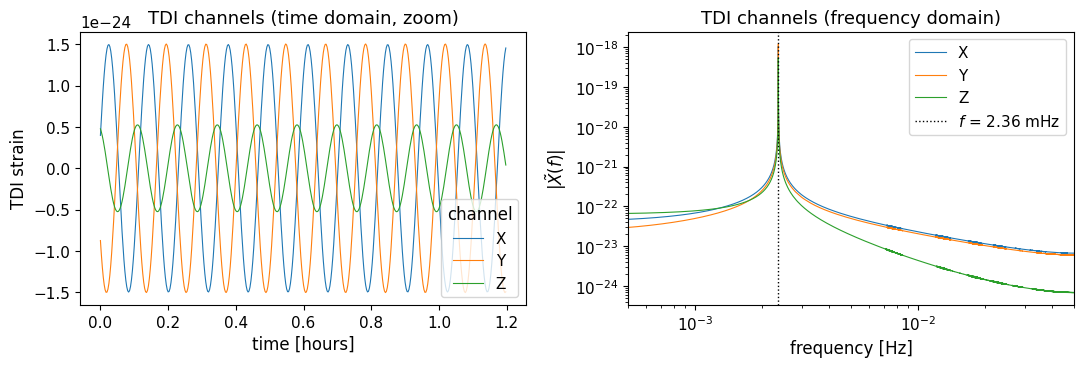

In [3]:
# time domain (a short zoom) and the frequency content of the X channel
tt = np.arange(len(XYZ[0])) * dt / 86400.0    # days since the trimmed start
zoom = tt < 0.05                              # ~ first 1.2 hours

fig, (a0, a1) = plt.subplots(1, 2, figsize=(11, 4))
for lab, chan, c in zip("XYZ", XYZ, ("C0", "C1", "C2")):
    a0.plot(tt[zoom] * 24.0, np.asarray(chan)[zoom], color=c, lw=0.8, label=lab)
a0.set(xlabel="time [hours]", ylabel="TDI strain", title="TDI channels (time domain, zoom)")
a0.legend(title="channel")

# frequency content via the domain classes from notebook 02
from lisatools.domains import TDSettings, TDSignal
fd = TDSignal(np.asarray(XYZ), TDSettings(N=len(XYZ[0]), dt=dt, force_backend="cpu")).fft()
for lab, i, c in zip("XYZ", range(3), ("C0", "C1", "C2")):
    a1.loglog(np.asarray(fd.f_arr), np.abs(np.asarray(fd.arr[i])), color=c, lw=0.8, label=lab)
a1.axvline(f, color="k", ls=":", lw=1, label=f"$f$ = {f*1e3:.2f} mHz")
a1.set(xlabel="frequency [Hz]", ylabel=r"$|\tilde{X}(f)|$",
       title="TDI channels (frequency domain)", xlim=(5e-4, 5e-2))
a1.legend()
fig.tight_layout()
plt.show()

## Going deeper: `pyResponseTDI` and TDI-on-the-fly

### `pyResponseTDI` — the engine underneath

`ResponseWrapper` is a convenience layer. The actual computation is done by
**`pyResponseTDI`** (`lisatools.response`), the lower-level engine that runs
the two physical steps on a complex time series:

1. **projection** — `get_projections(input, lam, beta, ...)` projects `h_+/h_x`
   onto each of the six inter-spacecraft links, applying the geometric antenna
   pattern and the light-travel-time delays from the `Orbits`;
2. **TDI combination** — `get_tdi_delays()` combines those single-link
   measurements with the delay pattern of the chosen TDI generation into the
   final X, Y, Z (or A, E, T) channels.

`ResponseWrapper` just owns the waveform generator, converts `Tobs`→`num_pts`,
pulls the sky coordinates out of the parameter list, and drives these two calls.
Construct the engine directly when you want to inspect the intermediate link
projections or supply a custom TDI combination.

In [4]:
from lisatools.response import pyResponseTDI

resp = pyResponseTDI(
    1.0 / dt,                 # sampling frequency [Hz]
    len(XYZ[0]),              # number of samples
    order=25,
    tdi="2nd generation",
    tdi_chan="XYZ",
    orbits=EqualArmlengthOrbits(force_backend="cpu"),
    force_backend="cpu",
)
print("engine:", type(resp).__name__)
print("  TDI channels :", resp.tdi_chan)
print("  # samples    :", resp.num_pts)
print("  pipeline     : get_projections(h, lam, beta, ...)  ->  get_tdi_delays()")
print("  (these are exactly the two calls ResponseWrapper makes for you)")

engine: pyResponseTDI
  TDI channels : XYZ
  # samples    : 155790
  pipeline     : get_projections(h, lam, beta, ...)  ->  get_tdi_delays()
  (these are exactly the two calls ResponseWrapper makes for you)


### TDI-on-the-fly — fast per-source responses for the global fit

`ResponseWrapper`/`pyResponseTDI` build a *dense* time series and project it —
correct and general, but expensive when a sampler needs the response of the
same source class millions of times. The **TDI-on-the-fly** family
(`lisatools.response.tdionfly`) is the fast path: it evaluates the TDI response
directly in an amplitude/phase representation on a **sparse spline time grid**,
so a single source costs a small fraction of a full projection. It is
GPU-accelerated and is what the stock global fit uses for its per-source
likelihoods:

- `GBTDIonTheFly` / `GBFDTDIonTheFly` — Galactic binaries,
- `SOBBHTDIonTheFly` — stellar-origin black-hole binaries,
- `TDTDIonTheFly` / `FDTDIonTheFly` — spline-fed intrinsic waveforms
  (e.g. massive black-hole binaries), in the time or frequency domain.

These are the response half of the fast per-source likelihoods discussed in
[`06`](06_SourceWaveforms.ipynb) and [`03`](03_StockGlobalFitsInDepth.ipynb); the
seed for the direct-response path here is LAT's
`examples/lisa_response_tutorial.ipynb`.